# Simulated HCV Assay Evaluation Project

This project simulates and analyzes diagnostic assay data inspired by published HCV assay evaluation research.

In [1]:
import pandas as pd
import numpy as np

In [2]:
#reproducability 
np.random.seed (42)

In [3]:
#number of unique patients
n_patients = 450

In [4]:
#create patient IDs
patient_ids=np.arange (1001, 1001 + n_patients)
patient_ids[:10]

array([1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010])

In [6]:
#simulate age
ages=np.random.normal(
    loc=50,
    scale=16.7,
    size=n_patients

)
# constrain ages to realistic range
ages = np.clip(ages, 3, 87)

# convert to integers
ages = ages.astype(int)

# preview first 10 ages
ages[:10]

array([58, 47, 60, 75, 46, 46, 76, 62, 42, 59])

In [11]:
#simulate sex distribution
sexes= np.random.choice(
    ['M', 'F'],
    size=n_patients,
    p=[0.55,  0.45]
    
)

sexes[:30]

array(['F', 'F', 'M', 'M', 'F', 'M', 'F', 'M', 'F', 'F', 'F', 'M', 'F',
       'M', 'M', 'F', 'F', 'F', 'F', 'M', 'M', 'F', 'M', 'M', 'M', 'M',
       'M', 'M', 'M', 'M'], dtype='<U1')

In [12]:
# build patient dataframe
patients_df = pd.DataFrame({
    'patient_id': patient_ids,
    'age': ages,
    'sex': sexes
})

# preview first rows
patients_df.head()

,patient_id,age,sex
0,1001,58,F
1,1002,47,F
2,1003,60,M
3,1004,75,M
4,1005,46,F


In [13]:
# dataset structure
patients_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   patient_id  450 non-null    int32 
 1   age         450 non-null    int32 
 2   sex         450 non-null    object
dtypes: int32(2), object(1)
memory usage: 7.2+ KB


In [14]:
# age summary statistics
patients_df['age'].describe()

count    450.000000
mean      49.684444
std       15.910887
min        3.000000
25%       38.000000
50%       50.000000
75%       60.000000
max       87.000000
Name: age, dtype: float64

In [15]:
# sex distribution
patients_df['sex'].value_counts(normalize=True)

M    0.52
F    0.48
Name: sex, dtype: float64

In [17]:
# assign number of specimens per patient

specimen_counts = np.random.choice(
    [1, 2, 3, 4],
    size=n_patients,
    p=[0.90, 0.07, 0.02, 0.01]
)

# preview first 20 values
specimen_counts[:20]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1])

In [18]:
# add specimen counts to patient table

patients_df['specimen_count'] = specimen_counts

patients_df.head()

,patient_id,age,sex,specimen_count
0,1001,58,F,1
1,1002,47,F,1
2,1003,60,M,1
3,1004,75,M,1
4,1005,46,F,1


In [19]:
# create empty list to store specimen rows
specimen_rows = []

# initialize specimen ID counter
specimen_id = 1

# loop through each patient
for _, row in patients_df.iterrows():

    # get patient ID
    patient_id = row['patient_id']

    # get number of specimens
    specimen_count = row['specimen_count']

    # create specimen rows
    for specimen_number in range(1, specimen_count + 1):

        specimen_rows.append({
            'specimen_id': specimen_id,
            'patient_id': patient_id,
            'specimen_number': specimen_number
        })

        specimen_id += 1

In [21]:
# create specimen dataframe
specimens_df = pd.DataFrame(specimen_rows)

# preview first rows
specimens_df.head()

,specimen_id,patient_id,specimen_number
0,1,1001,1
1,2,1002,1
2,3,1003,1
3,4,1004,1
4,5,1005,1


In [22]:
# specimen dataframe structure
specimens_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 512 entries, 0 to 511
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   specimen_id      512 non-null    int64
 1   patient_id       512 non-null    int64
 2   specimen_number  512 non-null    int64
dtypes: int64(3)
memory usage: 12.1 KB


In [23]:
# total number of specimens
len(specimens_df)

512

In [24]:
# assign specimen type

specimens_df['specimen_type'] = np.where(
    specimens_df['specimen_number'] == 1,
    np.random.choice(
        ['Screening', 'Monitoring'],
        size=len(specimens_df),
        p=[0.56, 0.44]
    ),
    'Monitoring'
)

# preview
specimens_df.head(10)

,specimen_id,patient_id,specimen_number,specimen_type
0,1,1001,1,Monitoring
1,2,1002,1,Screening
2,3,1003,1,Screening
3,4,1004,1,Screening
4,5,1005,1,Screening
5,6,1006,1,Screening
6,7,1007,1,Screening
7,8,1008,1,Screening
8,9,1009,1,Monitoring
9,10,1010,1,Monitoring


In [25]:
# specimen type distribution
specimens_df['specimen_type'].value_counts()

Screening     265
Monitoring    247
Name: specimen_type, dtype: int64

In [26]:
# create random base dates

base_dates = pd.to_datetime(
    np.random.choice(
        pd.date_range('2023-01-01', '2024-12-31'),
        size=len(specimens_df)
    )
)

base_dates[:5]

DatetimeIndex(['2024-04-27', '2023-04-21', '2023-05-19', '2024-03-10',
               '2024-05-23'],
              dtype='datetime64[ns]', freq=None)

In [27]:
# add collection dates

specimens_df['collection_date'] = base_dates

# preview
specimens_df.head()

,specimen_id,patient_id,specimen_number,specimen_type,collection_date
0,1,1001,1,Monitoring,2024-04-27
1,2,1002,1,Screening,2023-04-21
2,3,1003,1,Screening,2023-05-19
3,4,1004,1,Screening,2024-03-10
4,5,1005,1,Screening,2024-05-23


In [28]:
# sort by patient and date

specimens_df = specimens_df.sort_values(
    by=['patient_id', 'collection_date']
)

# reset index
specimens_df = specimens_df.reset_index(drop=True)

specimens_df.head(10)

,specimen_id,patient_id,specimen_number,specimen_type,collection_date
0,1,1001,1,Monitoring,2024-04-27
1,2,1002,1,Screening,2023-04-21
2,3,1003,1,Screening,2023-05-19
3,4,1004,1,Screening,2024-03-10
4,5,1005,1,Screening,2024-05-23
5,6,1006,1,Screening,2023-09-30
6,7,1007,1,Screening,2023-04-09
7,8,1008,1,Screening,2023-04-14
8,9,1009,1,Monitoring,2023-08-02
9,10,1010,1,Monitoring,2024-10-25


In [29]:
# simulate viral loads using lognormal distribution, viral load doesn't follow normal dis

viral_loads = np.random.lognormal(
    mean=10,
    sigma=1.2,
    size=len(specimens_df)
)

# convert to integers
viral_loads = viral_loads.astype(int)

# preview
viral_loads[:10]

array([  6192,   8957, 131011,  16904,  31799,  78088,  38412,  42439,
        64440,   1737])

In [30]:
# add viral loads to dataframe

specimens_df['viral_load'] = viral_loads

# preview
specimens_df.head()

,specimen_id,patient_id,specimen_number,specimen_type,collection_date,viral_load
0,1,1001,1,Monitoring,2024-04-27,6192
1,2,1002,1,Screening,2023-04-21,8957
2,3,1003,1,Screening,2023-05-19,131011
3,4,1004,1,Screening,2024-03-10,16904
4,5,1005,1,Screening,2024-05-23,31799


In [31]:
# viral load summary statistics

specimens_df['viral_load'].describe()

count    5.120000e+02
mean     5.353185e+04
std      9.583678e+04
min      6.550000e+02
25%      1.022425e+04
50%      2.450050e+04
75%      5.588975e+04
max      1.101947e+06
Name: viral_load, dtype: float64

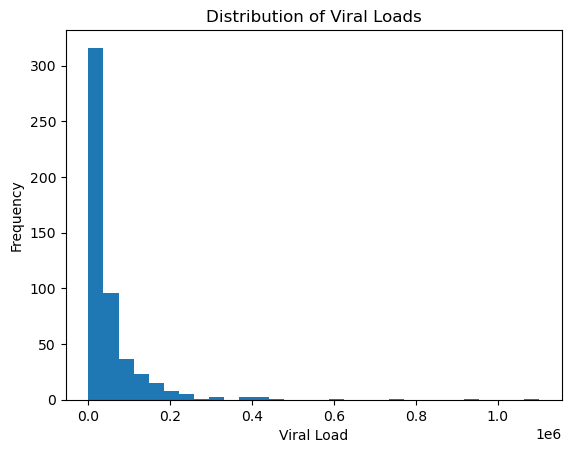

In [32]:
import matplotlib.pyplot as plt

# histogram of viral loads

plt.hist(specimens_df['viral_load'], bins=30)

plt.xlabel('Viral Load')
plt.ylabel('Frequency')
plt.title('Distribution of Viral Loads')

plt.show()

In [33]:
# randomly assign some specimens as negative

negative_mask = np.random.choice(
    [0, 1],
    size=len(specimens_df),
    p=[0.80, 0.20]
)

# set viral load to zero for negatives
specimens_df.loc[
    negative_mask == 1,
    'viral_load'
] = 0

In [34]:
# create NAAT result

specimens_df['naat_result'] = np.where(
    specimens_df['viral_load'] > 0,
    'Positive',
    'Negative'
)

# preview
specimens_df.head()

,specimen_id,patient_id,specimen_number,specimen_type,collection_date,viral_load,naat_result
0,1,1001,1,Monitoring,2024-04-27,6192,Positive
1,2,1002,1,Screening,2023-04-21,8957,Positive
2,3,1003,1,Screening,2023-05-19,131011,Positive
3,4,1004,1,Screening,2024-03-10,16904,Positive
4,5,1005,1,Screening,2024-05-23,31799,Positive


In [35]:
# NAAT result counts

specimens_df['naat_result'].value_counts()

Positive    417
Negative     95
Name: naat_result, dtype: int64

In [36]:
# summary statistics for positive viral loads

specimens_df.loc[
    specimens_df['naat_result'] == 'Positive',
    'viral_load'
].describe()

count    4.170000e+02
mean     5.403682e+04
std      9.840947e+04
min      6.550000e+02
25%      9.943000e+03
50%      2.376100e+04
75%      5.419500e+04
max      1.101947e+06
Name: viral_load, dtype: float64

In [37]:
# create antigen signal values for the Research use HCV assay

signal_noise = np.random.normal(
    loc=0,
    scale=0.5,
    size=len(specimens_df)
)

specimens_df['antigen_signal'] = (
    np.log10(specimens_df['viral_load'] + 1)
    + signal_noise
)

# prevent negative signals
specimens_df['antigen_signal'] = specimens_df[
    'antigen_signal'
].clip(lower=0)

# preview
specimens_df.head()

,specimen_id,patient_id,specimen_number,specimen_type,collection_date,viral_load,naat_result,antigen_signal
0,1,1001,1,Monitoring,2024-04-27,6192,Positive,3.811696
1,2,1002,1,Screening,2023-04-21,8957,Positive,3.399583
2,3,1003,1,Screening,2023-05-19,131011,Positive,4.536345
3,4,1004,1,Screening,2024-03-10,16904,Positive,4.073561
4,5,1005,1,Screening,2024-05-23,31799,Positive,4.152431


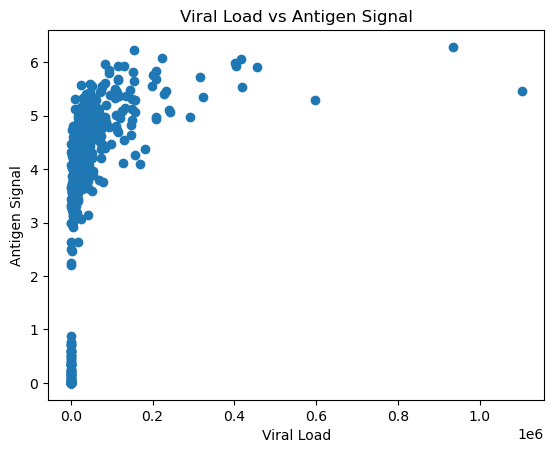

In [38]:
# scatterplot of viral load vs antigen signal

import matplotlib.pyplot as plt

plt.scatter(
    specimens_df['viral_load'],
    specimens_df['antigen_signal']
)

plt.xlabel('Viral Load')
plt.ylabel('Antigen Signal')
plt.title('Viral Load vs Antigen Signal')

plt.show()

In [39]:
# create antigen assay result

specimens_df['antigen_result'] = np.where(
    specimens_df['antigen_signal'] >= 1.0,
    'Positive',
    'Negative'
)

# preview
specimens_df.head()

,specimen_id,patient_id,specimen_number,specimen_type,collection_date,viral_load,naat_result,antigen_signal,antigen_result
0,1,1001,1,Monitoring,2024-04-27,6192,Positive,3.811696,Positive
1,2,1002,1,Screening,2023-04-21,8957,Positive,3.399583,Positive
2,3,1003,1,Screening,2023-05-19,131011,Positive,4.536345,Positive
3,4,1004,1,Screening,2024-03-10,16904,Positive,4.073561,Positive
4,5,1005,1,Screening,2024-05-23,31799,Positive,4.152431,Positive


In [40]:
# antigen result counts

specimens_df['antigen_result'].value_counts()

Positive    417
Negative     95
Name: antigen_result, dtype: int64

In [41]:
# compare NAAT and antigen results

pd.crosstab(
    specimens_df['naat_result'],
    specimens_df['antigen_result']
)

antigen_result,Negative,Positive
naat_result,,
Negative,95,0
Positive,0,417


In [42]:
# identify discordant cases

discordant_cases = specimens_df[
    specimens_df['naat_result']
    != specimens_df['antigen_result']
]

discordant_cases.head()

,specimen_id,patient_id,specimen_number,specimen_type,collection_date,viral_load,naat_result,antigen_signal,antigen_result


In [47]:
# identify low positive viral load specimens

low_positive_mask = (
    (specimens_df['viral_load'] > 500) &
    (specimens_df['viral_load'] < 5000)
)

# randomly select some low viral load positives
selected_indices = specimens_df[
    low_positive_mask
].sample(
    frac=0.30,
    random_state=42
).index

# force antigen result to negative
specimens_df.loc[
    selected_indices,
    'antigen_result'
] = 'Negative'

In [48]:
# discordant cases

discordant_cases = specimens_df[
    specimens_df['naat_result']
    != specimens_df['antigen_result']
]

len(discordant_cases)

14

In [49]:
# confusion matrix

confusion_matrix = pd.crosstab(
    specimens_df['naat_result'],
    specimens_df['antigen_result']
)

confusion_matrix

antigen_result,Negative,Positive
naat_result,,
Negative,95,0
Positive,14,403


In [50]:
# extract confusion matrix values

TN = confusion_matrix.loc['Negative', 'Negative']
TP = confusion_matrix.loc['Positive', 'Positive']
FN = confusion_matrix.loc['Positive', 'Negative']
FP = confusion_matrix.loc['Negative', 'Positive']

print("TN:", TN)
print("TP:", TP)
print("FN:", FN)
print("FP:", FP)

TN: 95
TP: 403
FN: 14
FP: 0


In [51]:
# sensitivity: ability to correctly detect positives

sensitivity = TP / (TP + FN)

print("Sensitivity:", sensitivity)

Sensitivity: 0.9664268585131894


In [52]:
# specificity

specificity = TN / (TN + FP)

print("Specificity:", specificity)

Specificity: 1.0


In [53]:
# overall concordance

concordance = (TP + TN) / len(specimens_df)

print("Concordance:", concordance)

Concordance: 0.97265625


In [54]:
# formatted performance metrics

print(f"Sensitivity: {sensitivity:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"Concordance: {concordance:.3f}")

Sensitivity: 0.966
Specificity: 1.000
Concordance: 0.973


In [56]:
from sklearn.metrics import cohen_kappa_score

# calculate Cohen's kappa

kappa = cohen_kappa_score(
    specimens_df['naat_result'],
    specimens_df['antigen_result']
)

print("Cohen's Kappa:", kappa)
print(f"Cohen's Kappa: {kappa:.3f}")

Cohen's Kappa: 0.9143996751773389
Cohen's Kappa: 0.914


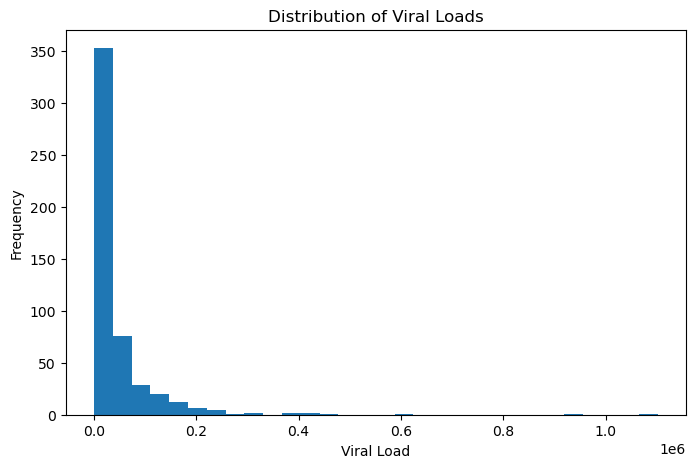

In [59]:
import matplotlib.pyplot as plt

# histogram of viral loads

plt.figure(figsize=(8,5))

plt.hist(
    specimens_df['viral_load'],
    bins=30
)

plt.xlabel('Viral Load')
plt.ylabel('Frequency')
plt.title('Distribution of Viral Loads')

plt.show()

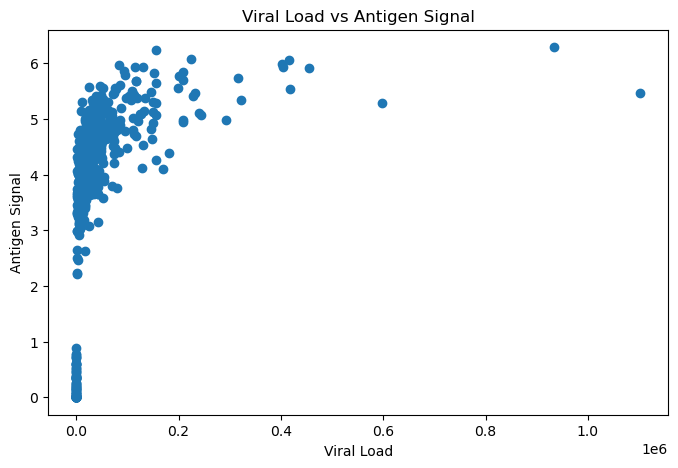

In [60]:
# scatterplot of viral load vs antigen signal

plt.figure(figsize=(8,5))

plt.scatter(
    specimens_df['viral_load'],
    specimens_df['antigen_signal']
)

plt.xlabel('Viral Load')
plt.ylabel('Antigen Signal')
plt.title('Viral Load vs Antigen Signal')

plt.show()

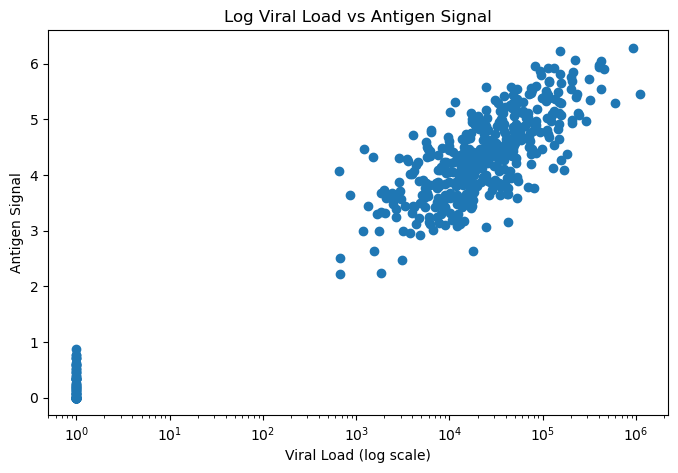

In [61]:
# scatterplot with log-scaled x-axis

plt.figure(figsize=(8,5))

plt.scatter(
    specimens_df['viral_load'] + 1,
    specimens_df['antigen_signal']
)

plt.xscale('log')

plt.xlabel('Viral Load (log scale)')
plt.ylabel('Antigen Signal')
plt.title('Log Viral Load vs Antigen Signal')

plt.show()

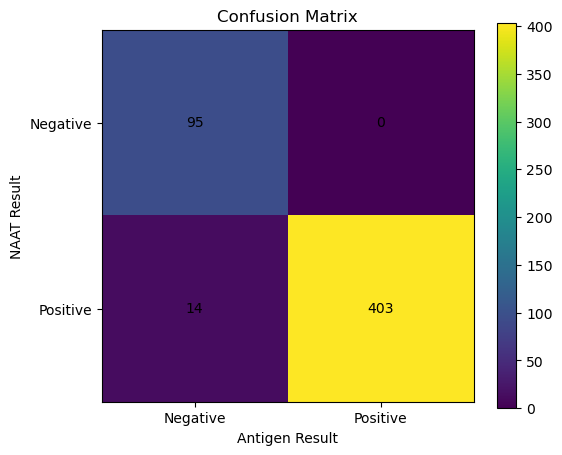

In [62]:
# visualize confusion matrix

plt.figure(figsize=(6,5))

plt.imshow(confusion_matrix)

plt.xticks(
    [0,1],
    ['Negative', 'Positive']
)

plt.yticks(
    [0,1],
    ['Negative', 'Positive']
)

plt.xlabel('Antigen Result')
plt.ylabel('NAAT Result')
plt.title('Confusion Matrix')

# add cell values
for i in range(confusion_matrix.shape[0]):
    for j in range(confusion_matrix.shape[1]):
        plt.text(
            j,
            i,
            confusion_matrix.iloc[i, j],
            ha='center',
            va='center'
        )

plt.colorbar()

plt.show()